# Análisis de hábitos de compra — Instacart

## Introducción

Instacart es una plataforma de entrega de comestibles similar a Uber Eats
o DoorDash. Este análisis explora los hábitos de compra de sus clientes a
partir de un conjunto de datos publicado por la empresa en 2017.

El objetivo es identificar patrones de comportamiento: en qué momentos
compran los usuarios, con qué frecuencia, qué productos piden más y cuáles
tienden a recomprar.

Los datos presentan valores ausentes y duplicados que requieren limpieza
previa al análisis.

## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

Se cargará cada archivo CSV con pd.read_csv() con "sep=';'" ya que requiero punto y coma como separador, se cargará cada Df en una celda indepentiente para tener mi codigo organizado, y con info() verifico el número de filas, columnas, tipos de datos y valores no nulos, para poder observar e identificar que situaciones hay con los valores ausentes o que tipo de problemas existen.

In [1]:
# importar librerías
import pandas as pd

In [1]:
# leer conjuntos de datos en los DataFrames
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
print("ORDERS:")
orders.info()

NameError: name 'pd' is not defined

In [2]:
# mostrar información del DataFrame 
products = pd.read_csv('/datasets/products.csv', sep=';')
print("PRODUCTS:")
products.info()

NameError: name 'pd' is not defined

In [3]:
# mostrar información del DataFrame

aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
print("AISLES:")
aisles.info()


NameError: name 'pd' is not defined

In [3]:
# mostrar información del DataFrame
departments = pd.read_csv('/datasets/departments.csv', sep=';')
print("DEPARTMENTS:")
departments.info()

DEPARTMENTS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [2]:

import pandas as pd

# mostrar información del DataFrame
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
print("ORDER_PRODUCTS:")
order_products.info()

ORDER_PRODUCTS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [28]:

# mostrar información del DataFrame
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')


In [32]:
# mostrar información del DataFrame
print("ORDERS:")
orders.info()
print("\nPRODUCTS:")
products.info()
print("\nAISLES:")
aisles.info()
print("\nDEPARTMENTS:")
departments.info()
print("\nORDER_PRODUCTS:")
order_products.info(show_counts=True)


ORDERS:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 478952 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478952 non-null  int64  
 1   user_id                 478952 non-null  int64  
 2   order_number            478952 non-null  int64  
 3   order_dow               478952 non-null  int64  
 4   order_hour_of_day       478952 non-null  int64  
 5   days_since_prior_order  450135 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 25.6 MB

PRODUCTS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   product_id          49694 non-null  int64 
 1   product_name        48436 non-null  object
 2   aisle_id            49694 non-null  int64 
 3   department_id       49694 non-null 

## Conclusiones

las ordenes son 478,952 con 6 columnas, y en days_since_prior_order hay 28,817 valores nulos, lo que es la resta de 478,952-450,135, 
hay en product 49,694 productos en 5 columnas, y la columna de product_name tiene 1,258 valores nulos, lo que es la resta de 49,694-48,486
en aisles, son 134 valores austentes
departments son 21 valores austentes, 
oredr_products son 4,545,007 en 4 columnas, la columna add_to_cart_order tiene 836 valores austentes lo que es la testa de 4,545,007-5,544,171

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

podria verificar con .info() para identificar las columnas ID que sean int64 
checar los duplicados para cada tabla, .duplicated().sum() para detectar las duplicadas, y eliminar con .drop_duplicates()
para los valores ausentes, usar .isna().sum() para identificar valores ausentes 
    con las orders days_since_prior_order los NaN serian el primer pedido del cliente

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [10]:
# Revisa si hay pedidos duplicados

print(orders.duplicated().sum())

15


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Se encontraron 15 lineas duplicadas en el Df orders, lo más probable es que se registre dos veces el mismo pedido

In [5]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
import pandas as pd
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
print(orders[orders.duplicated(keep=False)])
print(orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)])


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
30371    1918001   188546            14          3                  2   
99462     794638    50898            24          3                  2   
119251    408114    68324             4          3                  2   
142258   2845099    31189            11          3                  2   
145574    794638    50898            24          3                  2   
164581   1112182   202304            84          3                  2   
200059   1782114   106752             1          3                  2   
204042   2125197    14050            48          3                  2   
215294   2160484   107525            16          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
242618   1021560    53767             3          3                  2   
250626    467134    63189            21          3 

Se muestran los resultados, los pedidos que se han duplicado exactamente el mismo día y hora, el cual es el miercoles a las 2 am

In [15]:
# Elimina los pedidos duplicados
orders = orders.drop_duplicates()

In [16]:
# Vuelve a verificar si hay filas duplicadas
print(orders.duplicated().sum())


0


In [4]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print(orders['order_id'].duplicated().sum())

NameError: name 'orders' is not defined

Describe brevemente tus hallazgos y lo que hiciste con ellos

en las filas duplicadas den el DF en orders, son pedidos escencialmente el miercoles a las 2 am, order_dow=3 y order_hour_of_day=2
eliminando los duplicados con drop.duplicates(), la verificacion con orders.duplicated().sum() y ya con 0  orders['order_id'].duplicated().sum() lo confirmo, 

Sí se encontraron líneas duplicadas en el DataFrame orders. Todas las filas duplicadas tienen en común que fueron realizadas el miércoles "order_dow=3" a las 2:00 a.m. "order_hour_of_day=2", lo que sugiere un error del sistema que registró los mismos pedidos dos veces en ese horario específico.

### `products` data frame

In [18]:
# Verifica si hay filas totalmente duplicadas
print(products.duplicated().sum())

0


In [20]:
# Revisa únicamente si hay ID de productos duplicados
print(products['product_id'].duplicated().sum())

0


In [22]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products['product_name_upper'] = products['product_name'].str.upper()
print(products['product_name_upper'].duplicated().sum())

1361


In [23]:
# Revisa si hay nombres duplicados de productos no faltantes
print(products[products['product_name'].notna()]['product_name_upper'].duplicated().sum())

104


Describe brevemente tus hallazgos y lo que hiciste con ellos.

0 filas duplicadas y 0 product_id cada producto tiene un identificador unico

en variantes con mayusculas tengo 1,361 nombres repetidos, y 104 que no son Nan, entonces es la misma cosa, con un nombre distinto en product_id o tal vez es otra presentación del mismo producto. 


De encontraron 0 filas duplicadas con 0 product_id lo que indica que ya cada producto tiene un identificador unico.
Al comparar nombres ahora en mayusculs 1.361 nombres duplicados en total y 104 nombres sin contar los Nan, esto refleja que hay productos con el mismo nombre y diferente producto_id.
Mi decisión es conservar estas filas sin eliminarlas, ya que cada product_id unico y nombres iguales pueden ser diferentes presentaciones de un producto, 

### `departments` data frame

In [6]:
# Revisa si hay filas totalmente duplicadas
print(departments.duplicated().sum())
#corregido

0


In [27]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(departments['department_id'].duplicated().sum())

NameError: name 'departments' is not defined

Describe brevemente tus hallazgos y lo que hiciste con ellos.

hay 0 filas totalmente duplicadas y 0 en department_id dubles en el DF de departments, 

### `aisles` data frame

In [34]:
# Revisa si hay filas totalmente duplicadas
print(aisles.duplicated().sum())

0


In [35]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(aisles['aisle_id'].duplicated().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

hay 0 filas duplicadas y 0 en aisle_id duplicadas en el Df aisles. igualmente en departments, 

### `order_products` data frame

In [36]:
# Revisa si hay filas totalmente duplicadas
print(order_products.duplicated().sum())

0


In [37]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(order_products.duplicated(subset=['order_id', 'product_id']).sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

no hay filas duplicadas pues marcan 0  en ambas, no hay productos repetido del mismo pedido, 

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [39]:
# Encuentra los valores ausentes en la columna 'product_name'
print(products['product_name'].isna().sum())


1258


Describe brevemente cuáles son tus hallazgos.

tengo 1,258 valores ausentes en product_name, 

In [40]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
missing_products = products[products['product_name'].isna()]
print(missing_products['aisle_id'].unique())
print((missing_products['aisle_id'] == 100).all())


[100]
True


Describe brevemente cuáles son tus hallazgos.

si todos son los ID100 en aisle_id == 100 ques on True en todos, todos están dentro de la misma tabla

In [43]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print(missing_products['department_id'].unique())
print((missing_products['department_id'] == 21).all())


[21]
True


Describe brevemente cuáles son tus hallazgos.

son austentes los productos con id21 department_id== 21 son true para dodos, o sea que están concentrados



In [42]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.


print(aisles[aisles['aisle_id'] == 100])
print(departments[departments['department_id'] == 21])

    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

el pasillo 100 tiene por nombre missing al igual que el 21, os dos tienen por nombre "missing" algo interesante y que no me había pasado antes

In [45]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')

Describe brevemente tus hallazgos y lo que hiciste con ellos.

que cambiaron los valores Nan en product_name con valor "Unknown" con fillna("Unknown")

### `orders` data frame

In [46]:
# Encuentra los valores ausentes
print(orders['days_since_prior_order'].isna().sum())


28817


In [47]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
missing_days = orders[orders['days_since_prior_order'].isna()]
print((missing_days['order_number'] == 1).all())

True


Describe brevemente tus hallazgos y lo que hiciste con ellos.

tengo 28,817 valores Nan en days_since_prior_order y todos son de order_numer==1 devolviendo True 

### `order_products` data frame

In [8]:
# Encuentra los valores ausentes
print(order_products['add_to_cart_order'].isna().sum())

836


In [7]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?

print(order_products['add_to_cart_order'].min())
print(order_products['add_to_cart_order'].max())

1.0
64.0


la columna add_to_order tiene 836 valores ausentes, en los existentes se encuentra 1 como minimo y el 64 como maximo, 

In [5]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'


import pandas as pd
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')


orders_with_missing = order_products[order_products['add_to_cart_order'].isna()]['order_id']
print(orders_with_missing)

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


In [6]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

import pandas as pd
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

products_per_order = order_products.groupby('order_id')['product_id'].count()
missing_order_counts = products_per_order[orders_with_missing.unique()]
print((missing_order_counts > 64).all())
print(missing_order_counts.min())

True
65


Describe brevemente cuáles son tus hallazgos.

todos los pedidos con valores ausentes en add_to_cart_order exceden los 64 que contienen, el minimo son de 65 productos, y solo se guardan los primeros 64

In [54]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype('int64')

Describe brevemente tus hallazgos y lo que hiciste con ellos.

los valores ausentes en add_to_cart_order son 64 productos True con un minimo de 54 productos, 

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

en estos ejercicios se encontraron duplicados,, valores ausentes en 5 tablas:
Durante "orders" se eliminaron 15 filas duplicadas, las que se solicitaron en el día miercoles juistamente a las 2 am, estas se encontraban repetidas
En "products" no se eliminaron los 104 nombres duplicados por el "product_id" unico, y como se3 mencionó, pueden ser variantes de ese producto, hay 1,258 valores ausentes en product_name.
En "orders" los 28,817 en"days_since_prior_order se conservan, 
En "order_prodcuts" los 836 Nan en "add_to_cart_order" se reemplazaron, y se corresponden pedidos con más de 64 articulos, lo que es el tope del sistema.
En "departments" y "aisles" no hay valores que estén duplicados o sean ausentes. 

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [56]:
print(orders['order_hour_of_day'].min(), orders['order_hour_of_day'].max())

0 23


In [57]:
print(orders['order_dow'].min(), orders['order_dow'].max())

0 6


Escribe aquí tus conclusiones 
pues que se mantienen dentro de la oscilacion, entonces están correctos

en los rangos de las columnas order_hour_of_day y order_dow

    order_hour_of_day con un valor min de 0 y mas de 23 que es el rango de horas
    order_dow con valor minimo de 0 y maximo de 6, que es de 0=domingo a 6=sabado
    

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

NameError: name 'plt' is not defined

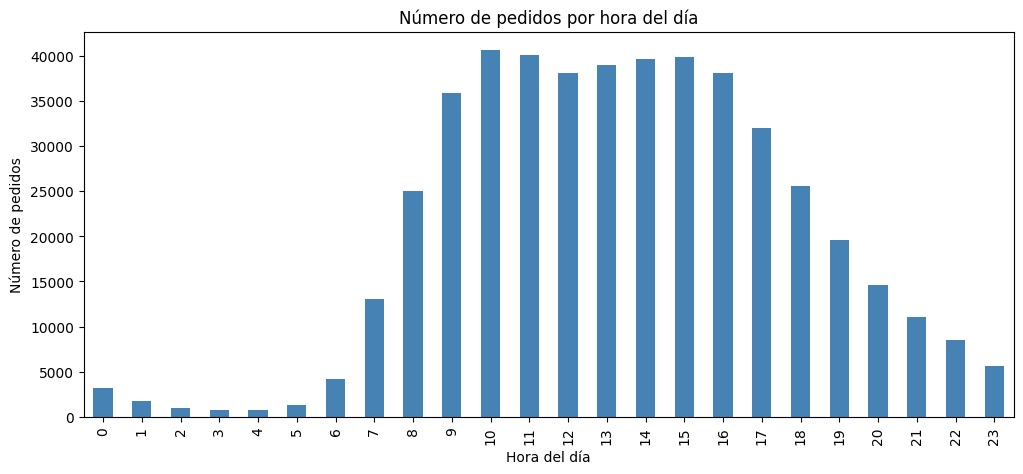

In [62]:
orders_by_hour = orders.groupby('order_hour_of_day')['order_id'].count()

orders_by_hour.plot(
    kind='bar',
    title='Número de pedidos por hora del día',
    xlabel='Hora del día',
    ylabel='Número de pedidos',
    figsize=[12, 5],
    color='steelblue'
)
plt.show()

Escribe aquí tus conclusiones
el grafico muestra que los pedidos tienen mayor concentración similar de 10 a 16, las dos primeras horas 10 y 11 son los de mayot afluencia con un minimo entre 2 y 4, incluso hay mayor actividad en medianoche, las compras se generan durante las horas de día, 

### [A3] ¿Qué día de la semana compran víveres las personas?

NameError: name 'plt' is not defined

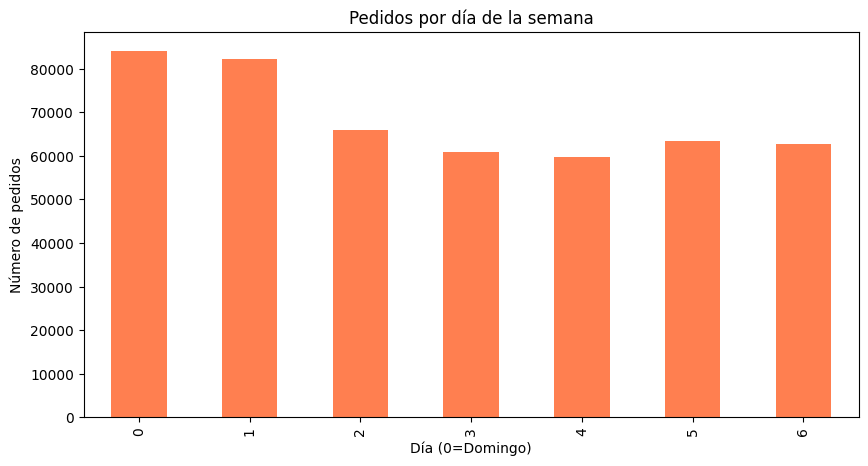

In [61]:
orders_by_dow = orders.groupby('order_dow')['order_id'].count()

orders_by_dow.plot(
    kind='bar',
    title='Pedidos por día de la semana',
    xlabel='Día (0=Domingo)',
    ylabel='Número de pedidos',
    figsize=[10, 5],
    color='coral'
)
plt.show()

Escribe aquí tus conclusiones
los días de mayor actividad con 0=domingo y 1=lunes, con 80,000 pedidos , los días siguientes se ve la disminucion, y oscilan entre 60,000 y 65,000 del día 2=Martes hasta 6=Sábado

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

NameError: name 'plt' is not defined

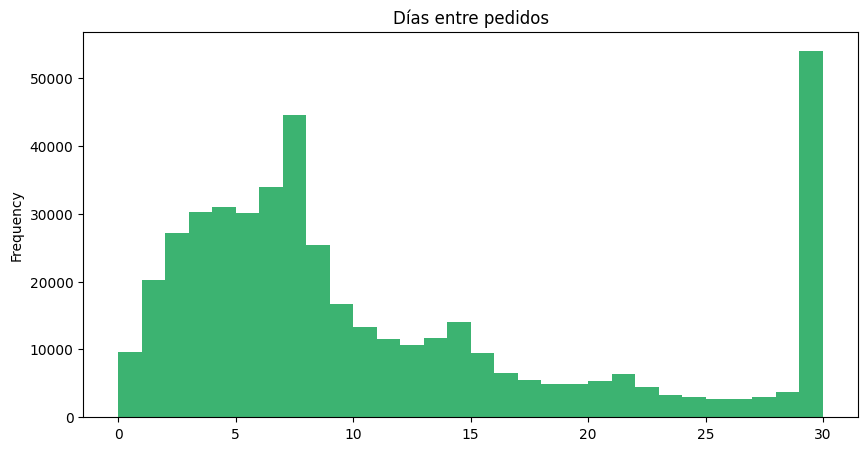

In [63]:
orders['days_since_prior_order'].plot(
    kind='hist',
    bins=30,
    title='Días entre pedidos',
    xlabel='Días',
    figsize=[10, 5],
    color='mediumseagreen'
)
plt.show()

print(orders['days_since_prior_order'].min())
print(orders['days_since_prior_order'].max())

Escribe aquí tus conclusiones
se observa la grafica del mes, lo que se observa los picos, son los días en el que los clientes piden durante el mismo día, 

al revisar los valores el minimo es de 0 días, que algunos clientes realizan dos pedidos en el mismo día, y la maxima es dd 30 días, lo que parece ser el limite, ya que los pedidos se acumulan en ese valor, en la grafica muestra dos momentos de mayor actividad, alrededor de los 7 días, que son los clientes que piden cada semana y en los 30 días, los clientes que lo hacen cada mes.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [64]:
wed = orders[orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
sat = orders[orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

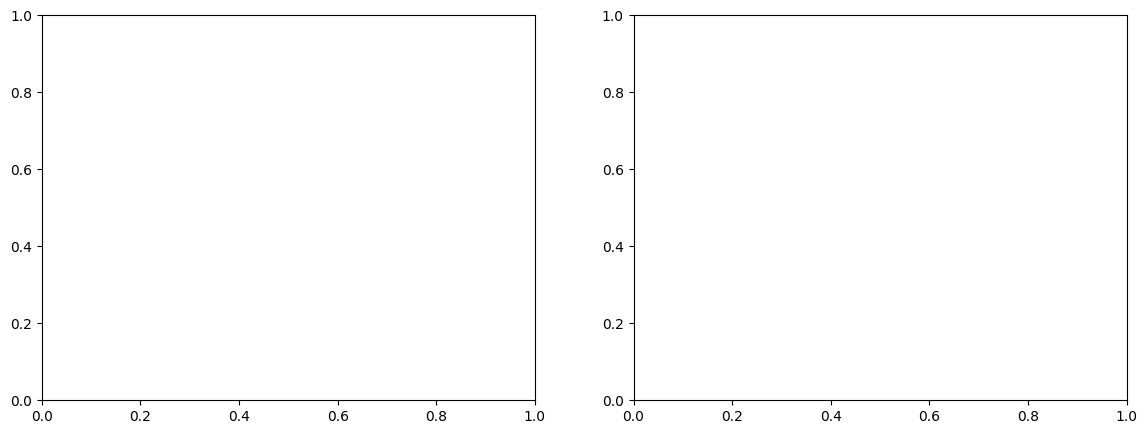

In [65]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=[14, 5])


In [66]:
wed.plot(kind='bar', ax=axes[0], title='Miércoles', color='steelblue')
sat.plot(kind='bar', ax=axes[1], title='Sábado', color='coral')

<AxesSubplot:title={'center':'Sábado'}>

In [67]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Escribe aquí tus conclusiones  los dos son el momento más alto al medio dá, el sabado se distribuye durante todo el día, y el miercoles es un punto más alto y concentrado 



### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

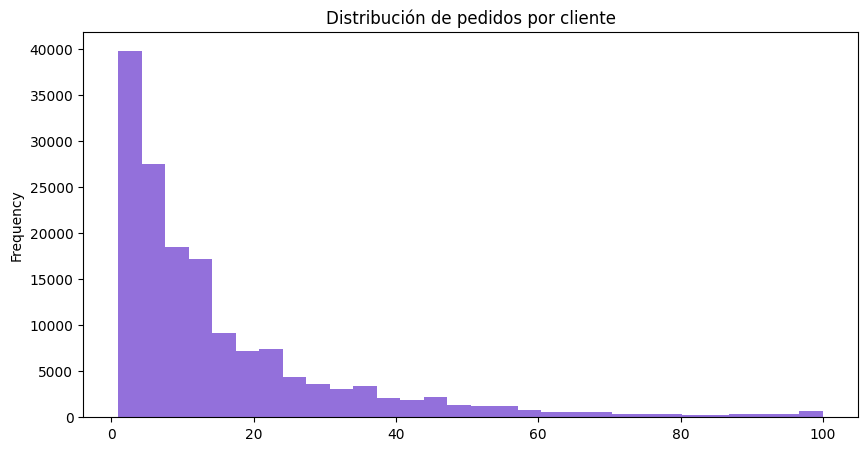

In [11]:

import pandas as pd
import matplotlib.pyplot as plt 

orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
orders_per_customer = orders.groupby('user_id')['order_number'].max()
orders_per_customer.plot(
    kind='hist',
    bins=30,
    title='Distribución de pedidos por cliente',
    xlabel='Número de pedidos',
    figsize=[10, 5],
    color='mediumpurple'
)
plt.show()

Escribe aquí tus conclusiones

la distribucion está sesgada en la derecha, lo cual hacen en su mayoria hara 5 pedidos, entre más pedidos se solicitan disminuye la grafica, 

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [18]:

import pandas as pd
import matplotlib.pyplot as plt

order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')

top20_products = (order_products
    .groupby('product_id')['order_id'].count()
    .reset_index()
    .rename(columns={'order_id': 'total_orders'})
    .sort_values('total_orders', ascending=False)
    .head(20)
    .merge(products[['product_id', 'product_name']], on='product_id')
)

    product_id              product_name  total_orders
0        24852                    Banana         66050
1        13176    Bag of Organic Bananas         53297
2        21137      Organic Strawberries         37039
3        21903      Organic Baby Spinach         33971
4        47209      Organic Hass Avocado         29773
5        47766           Organic Avocado         24689
6        47626               Large Lemon         21495
7        16797              Strawberries         20018
8        26209                     Limes         19690
9        27845        Organic Whole Milk         19600
10       27966       Organic Raspberries         19197
11       22935      Organic Yellow Onion         15898
12       24964            Organic Garlic         15292
13       45007          Organic Zucchini         14584
14       39275       Organic Blueberries         13879
15       49683            Cucumber Kirby         13675
16       28204        Organic Fuji Apple         12544
17        

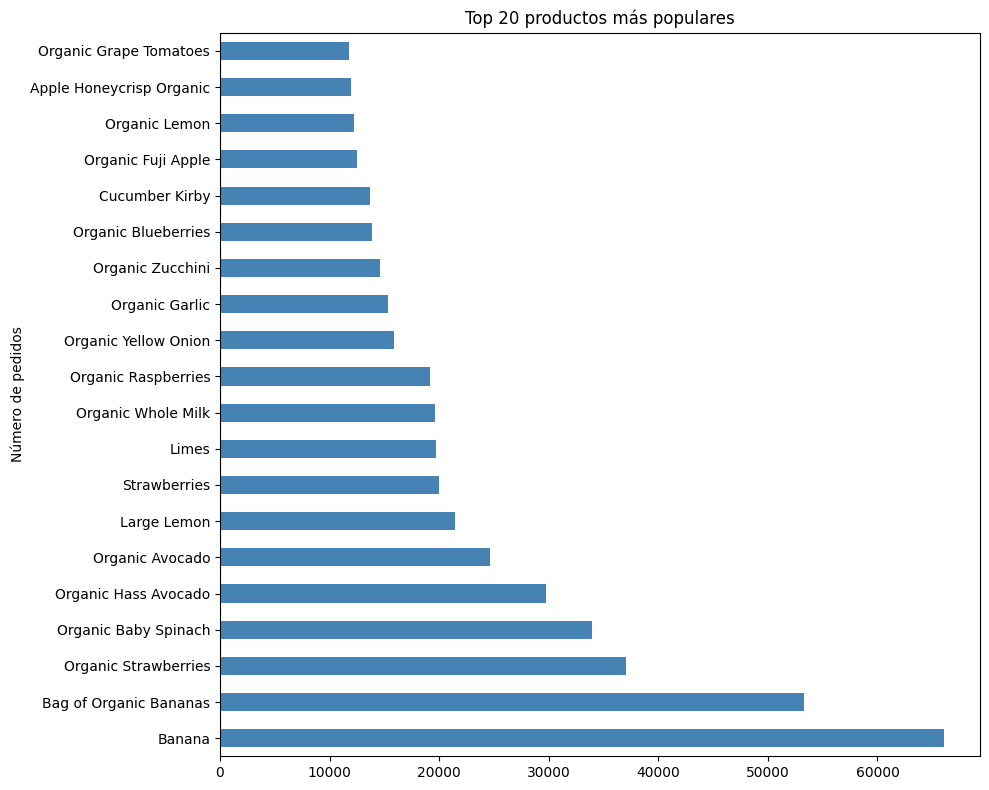

In [19]:
print(top20_products[['product_id', 'product_name', 'total_orders']])

top20_products.plot(
    kind='barh',
    x='product_name',
    y='total_orders',
    title='Top 20 productos más populares',
    xlabel='Número de pedidos',
    figsize=[10, 8],
    color='steelblue',
    legend=False
)
plt.tight_layout()
plt.show()


Escribe aquí tus conclusiones
existen más pedidos de drutas y verduras organicas que los demás 

los 20 productos mas populares son entre frutas y verduras frescas, con preferencia de productos organicos, la banana es la mayor con más de 60,000 pedidos, y arriba el segundo que sería la bolsa de bananas organicas, con 53297, de hecho parece que la palabra organic es la que hace que se venda más los productos,

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

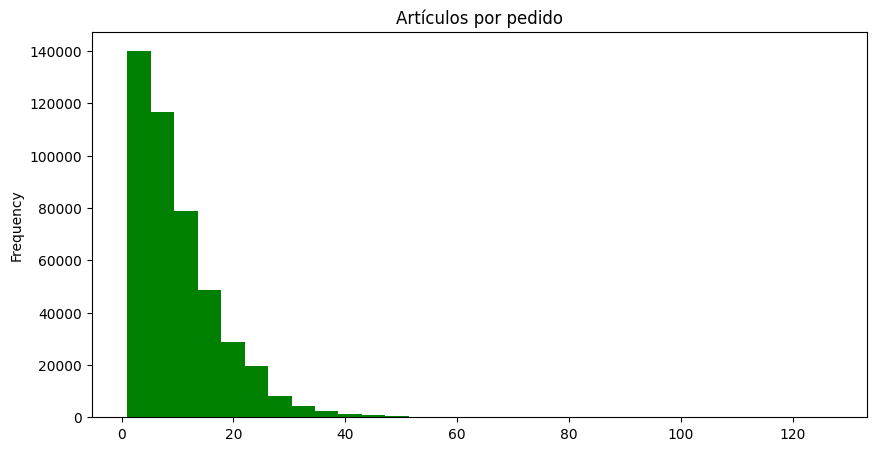

In [72]:
items_per_order = order_products.groupby('order_id')['product_id'].count()

items_per_order.plot(
    kind='hist',
    bins=30,
    title='Artículos por pedido',
    xlabel='Número de artículos',
    figsize=[10, 5],
    color='green'
)
plt.show()

Escribe aquí tus conclusiones

igul se encuentra sesgada a la derecja, los pedidos tienen entre 1 y 10 articulos, las dos primeras son las que muestran la mayor cantidad,los 40 son casi nulos, y conforme va incrementrando el numero decrece la grafica

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

    product_id              product_name  total_reorders
0        24852                    Banana           55763
1        13176    Bag of Organic Bananas           44450
2        21137      Organic Strawberries           28639
3        21903      Organic Baby Spinach           26233
4        47209      Organic Hass Avocado           23629
5        47766           Organic Avocado           18743
6        27845        Organic Whole Milk           16251
7        47626               Large Lemon           15044
8        27966       Organic Raspberries           14748
9        16797              Strawberries           13945
10       26209                     Limes           13327
11       22935      Organic Yellow Onion           11145
12       24964            Organic Garlic           10411
13       45007          Organic Zucchini           10076
14       49683            Cucumber Kirby            9538
15       28204        Organic Fuji Apple            8989
16        8277  Apple Honeycris

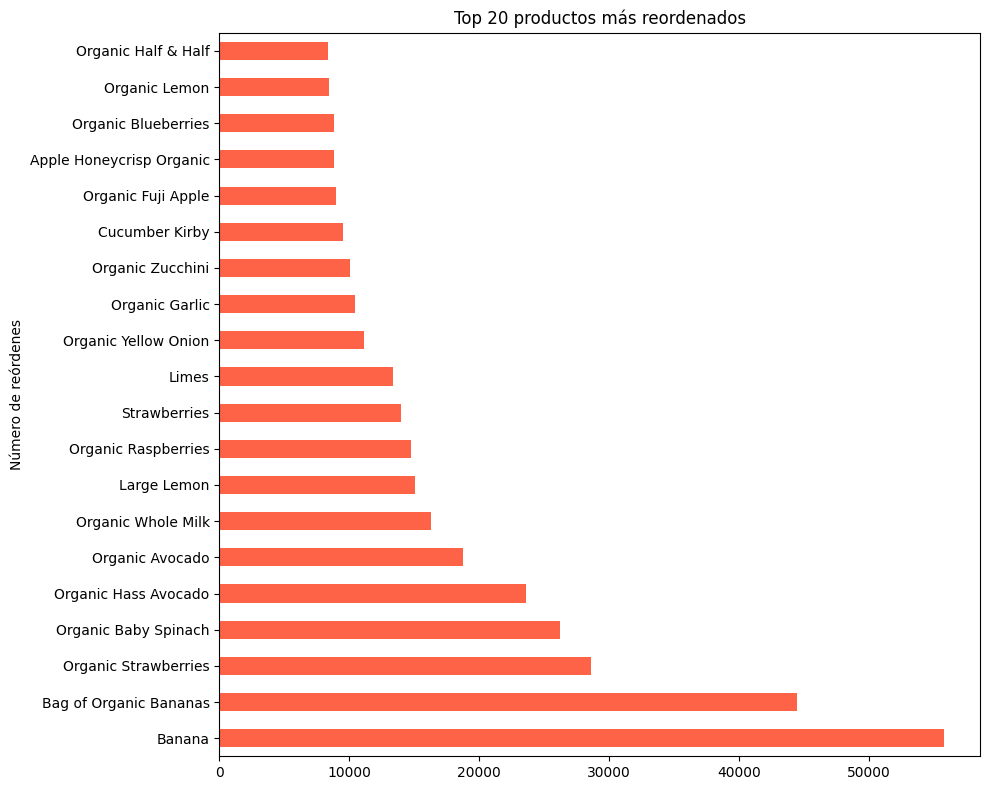

In [22]:

import pandas as pd
import matplotlib.pyplot as plt

order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')

top20_reordered = (order_products[order_products['reordered'] == 1]
    .groupby('product_id')['reordered'].count()
    .reset_index()
    .rename(columns={'reordered': 'total_reorders'})
    .sort_values('total_reorders', ascending=False)
    .head(20)
    .merge(products[['product_id', 'product_name']], on='product_id')
)

print(top20_reordered[['product_id', 'product_name', 'total_reorders']])

top20_reordered.plot(
    kind='barh',
    x='product_name',
    y='total_reorders',
    title='Top 20 productos más reordenados',
    xlabel='Número de reórdenes',
    figsize=[10, 8],
    color='tomato',
    legend=False
)
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones

pues basicamente corresponde a la grafica anterior, banana igual con la mayor cantidad de ordenes lo que son 55,763 ordenes, seguido por la bolsa de bananas organicas con 44,450 

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

       product_id  total  reorders  reorder_rate  \
13453       14721      1         1           1.0   
19195       20949      3         3           1.0   
6136         6723     10        10           1.0   
6144         6732      3         3           1.0   
41319       45088      1         1           1.0   
41310       45078      1         1           1.0   
19258       21016      1         1           1.0   
19248       21005      2         2           1.0   
32273       35192      2         2           1.0   
32277       35197      1         1           1.0   

                                            product_name  
13453                            Bone Strength Take Care  
19195                           Vanilla Sandwich Cookies  
6136                                    Palmiers- Petite  
6144                   Naturally Sparkling Mineral Water  
41319  California Dill Pollen & Garlic Goat Cheese & ...  
41310                                       Pomegranatea  
19258       Pa

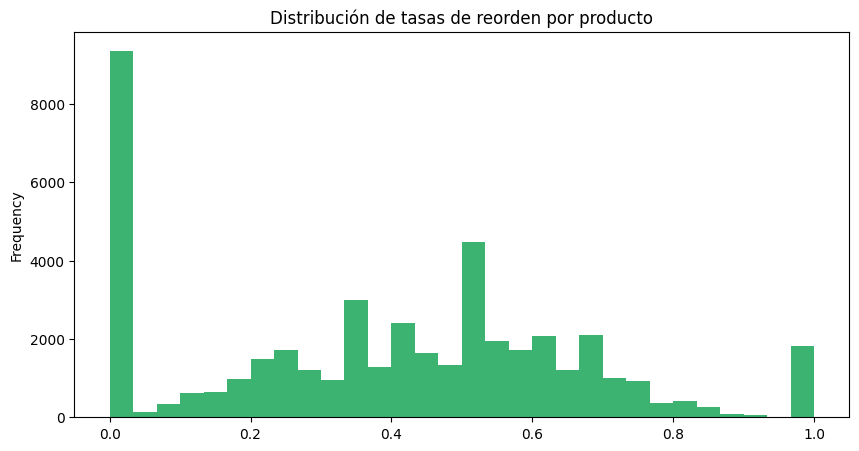

In [23]:

import pandas as pd
import matplotlib.pyplot as plt

order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')

reorder_rate = (order_products
    .groupby('product_id')
    .agg(total=('reordered', 'count'), reorders=('reordered', 'sum'))
)

reorder_rate['reorder_rate'] = reorder_rate['reorders'] / reorder_rate['total']
reorder_rate = reorder_rate.merge(products[['product_id', 'product_name']], on='product_id')

print(reorder_rate.sort_values('reorder_rate', ascending=False).head(10))

# Gráfico de distribución completa de tasas de reorden
reorder_rate['reorder_rate'].plot(
    kind='hist',
    bins=30,
    title='Distribución de tasas de reorden por producto',
    xlabel='Tasa de reorden',
    figsize=[10, 5],
    color='mediumseagreen'
)
plt.show()

esta grafica es diferente, en el 1 muestra un pico, que es el consumo diario, es esto que indica que vuelve a recomprar el cliente??, cuando hay menos reorden  son los primeros, las que tienen mas baja de reorden casi 0 son los que los clientes llegan a comprar una vez y ya no los repiten 

la distribución de las tasas de reorden demustra la mayoria de los productos que tienen una tasa cercana a 0, y esto es un indicador de que estos productos se compran pocas veces o que no se repiten, el pico notable den la tasa que es igual a 1.0 son los ccliente que realizan un pedido, 
los prodcutos que tienen una tasa entre 0.4 y 0.6 representan articulos que se repiten aproximadamenta la mitad, y los productos más populares son comoo se ha ha mencionado la Banana o las bolsas Organicas que tienen tasas de reorden más altas, lo que demuestran comprar habituales de los cleintes. 

Escribe aquí tus conclusiones
Analizando la grafica, en su gran mayodía, los productos se agrupan cercanos al 0, lo que es indicador de productos que los clientes compran solo una unica vez, y que no se piden de nuebo, y en el lado opuesto, los productos tienen una tasa de 1.0, los cuales son los que aparecen en todos los pedidos del cliente, estos son las frutas, y dentro del rango de 0.4 y 0.6 son productos que algunas veces se repiten y otras no. 

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: reorder_rate, dtype: float64


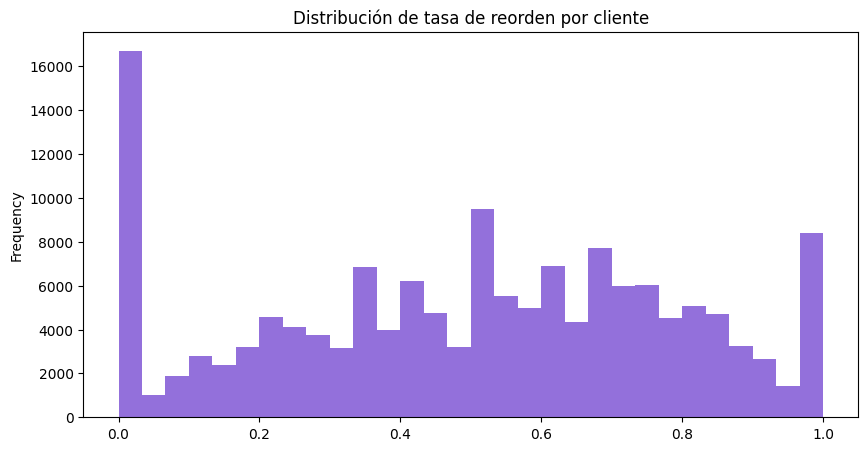

In [24]:

import pandas as pd
import matplotlib.pyplot as plt

order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')

user_reorder = (order_products
    .merge(orders[['order_id', 'user_id']], on='order_id')
    .groupby('user_id')
    .agg(total=('reordered', 'count'), reorders=('reordered', 'sum'))
)

user_reorder['reorder_rate'] = user_reorder['reorders'] / user_reorder['total']

print(user_reorder['reorder_rate'].describe())


user_reorder['reorder_rate'].plot(
    kind='hist',
    bins=30,
    title='Distribución de tasa de reorden por cliente',
    xlabel='Tasa de reorden',
    figsize=[10, 5],
    color='mediumpurple'
)
plt.show()

Escribe aquí tus conclusiones
el promedio es de 0.495859 lo que es la repeticion de casi la mitad, con minimo de 0 y maximo de 1 , el 75% es 0.7241

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')

top20_first = (order_products[order_products['add_to_cart_order'] == 1]
    .groupby('product_id')['order_id'].count()
    .reset_index()
    .rename(columns={'order_id': 'times_first'})
    .sort_values('times_first', ascending=False)
    .head(20)
    .merge(products[['product_id', 'product_name']], on='product_id')
)

print(top20_first[['product_id', 'product_name', 'times_first']])

    product_id                 product_name  times_first
0        24852                       Banana        15562
1        13176       Bag of Organic Bananas        11026
2        27845           Organic Whole Milk         4363
3        21137         Organic Strawberries         3946
4        47209         Organic Hass Avocado         3390
5        21903         Organic Baby Spinach         3336
6        47766              Organic Avocado         3044
7        19660                 Spring Water         2336
8        16797                 Strawberries         2308
9        27966          Organic Raspberries         2024
10       44632   Sparkling Water Grapefruit         1914
11       49235          Organic Half & Half         1797
12       47626                  Large Lemon         1737
13         196                         Soda         1733
14       38689     Organic Reduced Fat Milk         1397
15       26209                        Limes         1370
16       12341                H

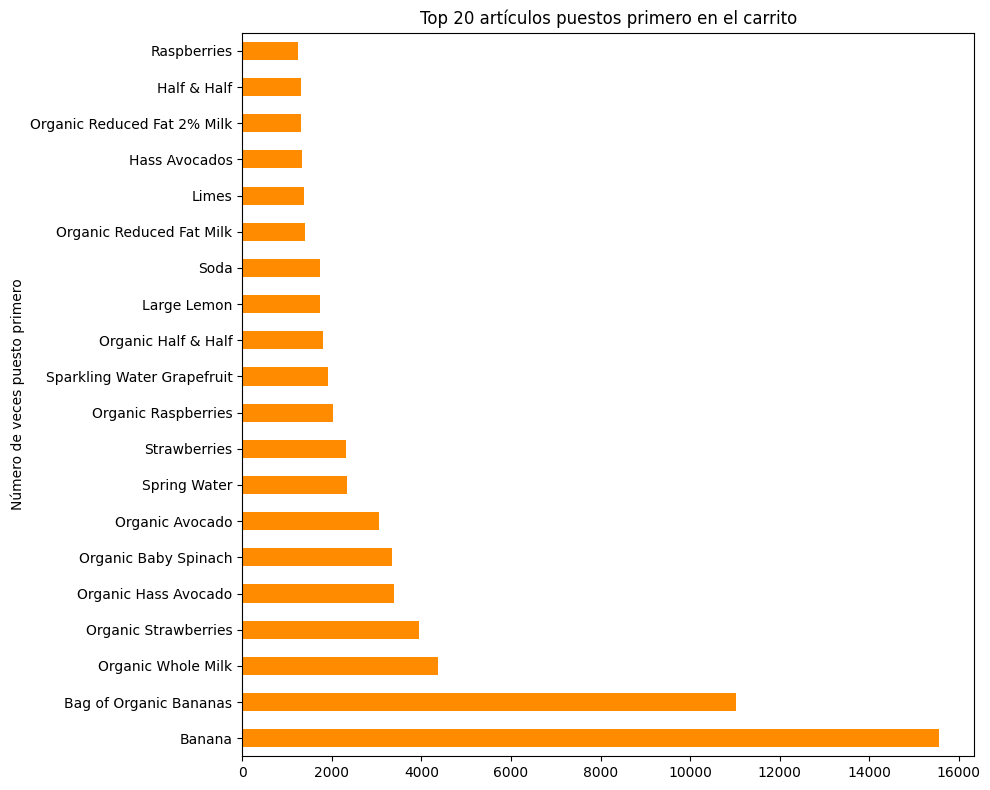

In [26]:
top20_first.plot(
    kind='barh',
    x='product_name',
    y='times_first',
    title='Top 20 artículos puestos primero en el carrito',
    xlabel='Número de veces puesto primero',
    figsize=[10, 8],
    color='darkorange',
    legend=False
)
plt.tight_layout()
plt.show()

Escribe aquí tus conclusiones
los más repetidos son los procutos top, loc cuales son las frutas y los organicos 

los 20 productos que las personas mas eligen sob frutas y verduras organicas, Banana igual es la mayor seguido de la bolsa de bananas organicas, que como en los ejercicios anteriores son los mas populares y ordenados, 

En mi analisis puedo observar que en los comportamientos de horarios hay una mayor afluencia entre 10 am y 4 pm, y con más movimiento los días Domingo y Lunes,, con una repeticón de 7 o 30 días, lo que son patrones de cada semana o de cada mes

en cuanto a las distribuciones, se realizan pedidos menores, regularmente entre 1 y 5 productos, y que la mayor venra son las frutas y verduras organicas, con un grande margen entre la bolsa de bananas organicas y bananas

encuanto a las reordenes, los clientes repiten el 49% de sus productos en cada pedido, y los productos más reordenados y los primeros en reelgirse son los mismos productos organicos, frescos, lo que indica que